# Part 1: Basic Network Traffic Statistics

Import & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!cp /content/drive/MyDrive/HERWAY/NSSAS3.zip /content/

In [10]:
import zipfile

with zipfile.ZipFile("NSSAS3.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [11]:
folder_path = "data"

files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

dfs = []
for f in files:
    print("Loading:", f)
    dfs.append(pd.read_csv(os.path.join(folder_path, f)))

df = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(df))
df.head()

Loading: network_analysis_data1.csv
Loading: network_analysis_data5.csv
Loading: network_analysis_data3.csv
Loading: network_analysis_data2.csv
Loading: network_analysis_data4.csv
Loading: network_analysis_data6.csv
Total rows: 2071657


,generated,appName,totalSourceBytes,totalDestinationBytes,totalDestinationPackets,totalSourcePackets,sourcePayloadAsBase64,sourcePayloadAsUTF,destinationPayloadAsBase64,destinationPayloadAsUTF,...,sourceTCPFlagsDescription,destinationTCPFlagsDescription,source,protocolName,sourcePort,destination,destinationPort,startDateTime,stopDateTime,Label
0,3/11/2014 18:21,Unknown_UDP,16076,0,0,178,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.5.122,udp_ip,5353,224.0.0.251,5353,6/13/2010 23:57,6/14/2010 0:11,Normal
1,3/11/2014 18:21,HTTPImageTransfer,384,0,0,6,NaN,NaN,NaN,NaN,...,"F,A",NaN,192.168.2.111,tcp_ip,4435,206.217.198.186,80,6/13/2010 23:58,6/14/2010 0:01,Normal
2,3/11/2014 18:21,DNS,171,642,4,2,NaN,NaN,NaN,NaN,...,NaN,NaN,192.168.4.119,udp_ip,4428,192.168.5.122,53,6/13/2010 23:58,6/13/2010 23:59,Normal
3,3/11/2014 18:21,HTTPImageTransfer,384,0,0,6,NaN,NaN,NaN,NaN,...,"F,A",NaN,192.168.4.119,tcp_ip,3639,219.94.203.105,80,6/13/2010 23:58,6/14/2010 0:00,Normal
4,3/11/2014 18:21,HTTPImageTransfer,186,128,2,2,NaN,NaN,NaN,NaN,...,"F,P,A",R,192.168.4.119,tcp_ip,3641,98.137.80.50,80,6/13/2010 23:58,6/13/2010 23:59,Normal


Inspecting Data

In [12]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2071657 entries, 0 to 2071656
Data columns (total 21 columns):
 #   Column                          Dtype 
---  ------                          ----- 
 0   generated                       object
 1   appName                         object
 2   totalSourceBytes                int64 
 3   totalDestinationBytes           int64 
 4   totalDestinationPackets         int64 
 5   totalSourcePackets              int64 
 6   sourcePayloadAsBase64           object
 7   sourcePayloadAsUTF              object
 8   destinationPayloadAsBase64      object
 9   destinationPayloadAsUTF         object
 10  direction                       object
 11  sourceTCPFlagsDescription       object
 12  destinationTCPFlagsDescription  object
 13  source                          object
 14  protocolName                    object
 15  sourcePort                      int64 
 16  destination                     object
 17  destinationPort                 int64 
 18  st

Index(['generated', 'appName', 'totalSourceBytes', 'totalDestinationBytes',
       'totalDestinationPackets', 'totalSourcePackets',
       'sourcePayloadAsBase64', 'sourcePayloadAsUTF',
       'destinationPayloadAsBase64', 'destinationPayloadAsUTF', 'direction',
       'sourceTCPFlagsDescription', 'destinationTCPFlagsDescription', 'source',
       'protocolName', 'sourcePort', 'destination', 'destinationPort',
       'startDateTime', 'stopDateTime', 'Label'],
      dtype='object')

The dataset consists of network flow logs containing source and destination IPs, protocol information, packet counts, byte counts, and timestamps. These attributes are used to analyze traffic patterns and detect anomalies.

Cleaning

In [14]:
# Convert timestamps
df['startDateTime'] = pd.to_datetime(df['startDateTime'])

# Remove rows with zero packets (avoid division issues)
df = df[(df['totalSourcePackets'] + df['totalDestinationPackets']) > 0]

# Sort by time
df = df.sort_values('startDateTime')

# Create time window (1 hour)
df['time_window'] = df['startDateTime'].dt.floor('1h')

A 1-hour time window is used to balance temporal granularity and computational efficiency. It captures short-term traffic variations while avoiding excessive noise.

1. Total No of Flows

In [15]:
total_flows = len(df)
print("Total flows:", total_flows)

Total flows: 2071657


The total number of flows represents the total number of network interactions recorded in the dataset.

2. Top-k Protocols

protocolName
tcp_ip     1644056
udp_ip      419246
icmp_ip       8211
igmp            77
ip              66
Name: count, dtype: int64


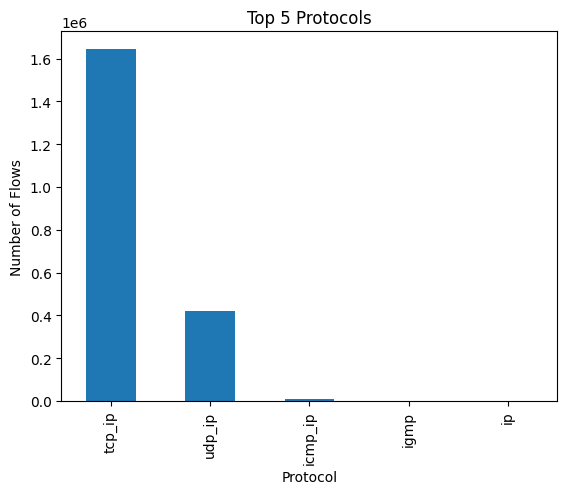

In [16]:
k = 5
top_protocols = df['protocolName'].value_counts().head(k)

print(top_protocols)

top_protocols.plot(kind='bar')
plt.title("Top 5 Protocols")
plt.xlabel("Protocol")
plt.ylabel("Number of Flows")
plt.show()

The most frequently used protocols are identified based on flow counts. This helps understand dominant communication patterns in the network.

3. Top Source & Destination IPs

Top Source IPs:
 source
192.168.5.122    268267
192.168.2.107    208379
192.168.4.118    135374
192.168.1.101    116292
192.168.4.121    105454
192.168.1.105    101359
192.168.2.109     99183
192.168.3.116     97241
192.168.2.110     90658
192.168.3.115     88915
Name: count, dtype: int64

Top Destination IPs:
 destination
198.164.30.2       232409
192.168.5.122      199437
203.73.24.75       193200
125.6.164.51       106826
67.220.214.50       49298
202.210.143.140     36189
82.98.86.183        25214
95.211.98.12        25095
209.112.44.10       21824
62.140.213.243      20509
Name: count, dtype: int64


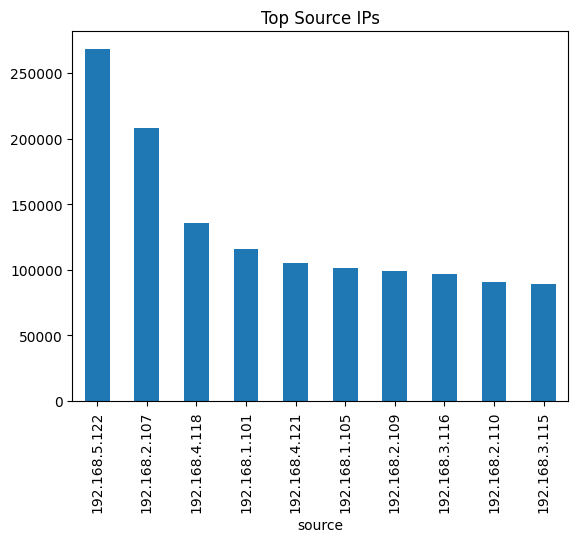

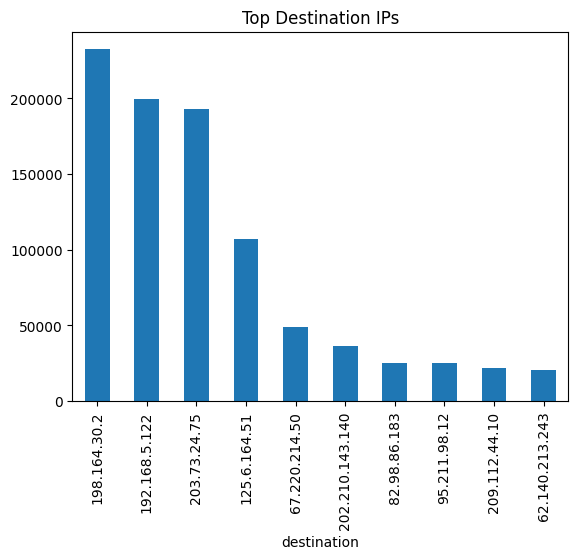

In [17]:
top_src = df['source'].value_counts().head(10)
top_dst = df['destination'].value_counts().head(10)

print("Top Source IPs:\n", top_src)
print("\nTop Destination IPs:\n", top_dst)

top_src.plot(kind='bar', title="Top Source IPs")
plt.show()

top_dst.plot(kind='bar', title="Top Destination IPs")
plt.show()

The most active source and destination IPs are identified using the number of flows. This highlights key entities generating and receiving traffic.

4. Average Packet Size

In [18]:
total_bytes = df['totalSourceBytes'].sum() + df['totalDestinationBytes'].sum()
total_packets = df['totalSourcePackets'].sum() + df['totalDestinationPackets'].sum()

avg_packet_size = total_bytes / total_packets

print("Average packet size:", avg_packet_size)

Average packet size: 736.9248946259129


The average packet size is computed using total bytes divided by total packets. This metric provides an overall estimate of traffic characteristics but may be influenced by outliers and large data transfers.

5. Top Source–Destination Pairs

In [19]:
df['pair'] = df['source'] + " → " + df['destination']

top_pairs = df['pair'].value_counts().head(3)

print(top_pairs)

pair
192.168.5.122 → 198.164.30.2    232409
192.168.2.107 → 125.6.164.51     58744
192.168.3.115 → 203.73.24.75     43785
Name: count, dtype: int64


Frequent source–destination pairs indicate persistent communication patterns, which may correspond to regular services or repeated interactions.

6. Consistent Communication

In [27]:
# Step 1: create pivot table
activity = df.groupby(['source', 'time_window']).size().unstack(fill_value=0)

# Step 2: compute std across time
consistency = activity.std(axis=1).sort_values()

# Step 3: get most consistent
consistent_ips = consistency.head(10)

consistent_ips

,0
source,
194.72.238.61,0.082761
216.114.79.153,0.082761
68.178.195.144,0.082761
212.159.0.20,0.082761
200.75.72.185,0.082761
201.38.0.130,0.082761
190.220.227.179,0.082761
187.62.24.79,0.082761
212.60.192.30,0.082761


Consistency is measured using the standard deviation of traffic counts across time windows. Missing activity is treated as zero to ensure accurate representation. IPs with low variance exhibit stable communication patterns.

In [28]:
inconsistent_ips = consistency.sort_values(ascending=False).head(10)
inconsistent_ips

,0
source,
192.168.2.107,2758.907927
192.168.2.106,1960.836142
192.168.1.105,1868.114906
192.168.2.110,1637.930712
192.168.3.116,1449.733842
192.168.5.122,1385.445294
192.168.4.118,1372.309056
192.168.4.121,1294.996354
192.168.2.109,1267.984435


IPs that appear consistently across multiple time windows are likely to represent stable communication patterns such as servers or periodic processes.

IPs with high standard deviation exhibit bursty communication behavior, where traffic volume varies significantly across time windows. Such behavior may correspond to active users, dynamic workloads, or potential anomalous activity such as scanning or attack bursts.

Compared to consistent IPs, which show stable communication patterns, these high-variance IPs demonstrate irregular activity, making them potential candidates for further anomaly investigation.

7. Traffic Spikes Detection

In [21]:
traffic = df.groupby('time_window').size()

mean = traffic.mean()
std = traffic.std()

threshold = mean + 3 * std

spikes = traffic[traffic > threshold]

print("Number of spikes:", len(spikes))

Number of spikes: 2


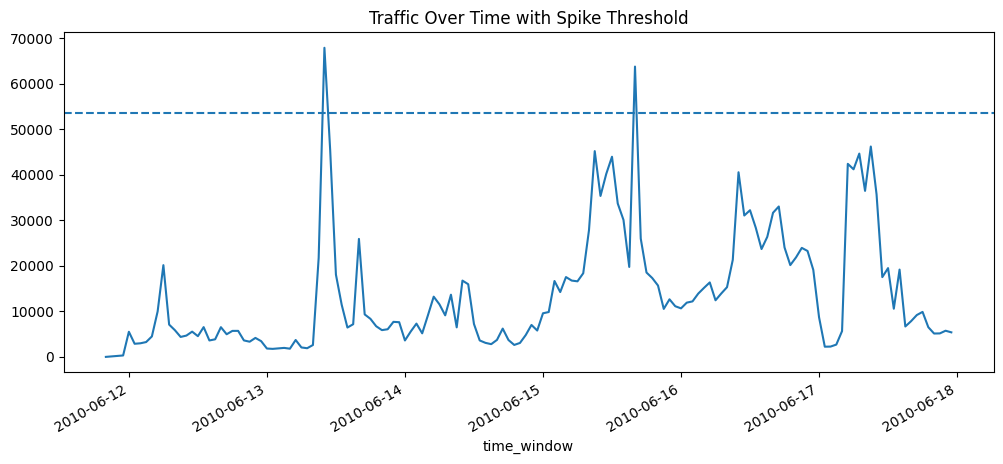

In [22]:
plt.figure(figsize=(12,5))
traffic.plot()
plt.axhline(threshold, linestyle='--')
plt.title("Traffic Over Time with Spike Threshold")
plt.show()

Traffic spikes are identified using the 3σ rule (mean + 3×standard deviation). This method detects statistically rare events that may indicate anomalies such as DDoS attacks or sudden traffic bursts.

8. Variance of Packet Size

In [23]:
df['packet_size'] = (
    (df['totalSourceBytes'] + df['totalDestinationBytes']) /
    (df['totalSourcePackets'] + df['totalDestinationPackets'])
)

variance = df['packet_size'].var()

print("Packet size variance:", variance)

Packet size variance: 70795.81223939284


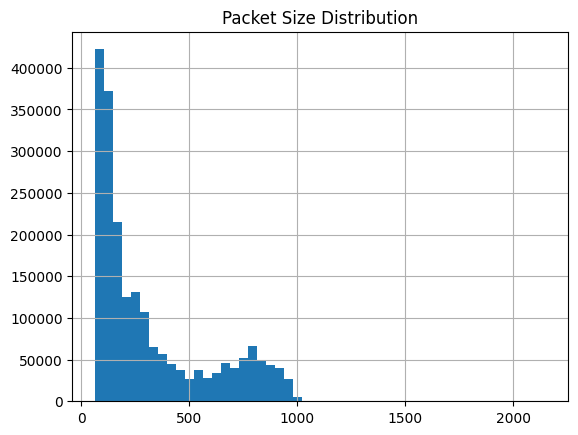

In [24]:
df['packet_size'].hist(bins=50)
plt.title("Packet Size Distribution")
plt.show()

High variance in packet size indicates a mix of small control packets and large data transfers, while low variance suggests uniform traffic patterns.

# Part 2: Traffic Estimation Using Sublinear Space